In [51]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import preprocess_input

In [52]:
RAW_PATH = r"D:\CODE\Alzheimer_Detection_And_Classification\data\raw_mri"
BASE_PATH = r"D:\CODE\Alzheimer_Detection_And_Classification\data"


In [53]:
def split_dataset_once(raw_path, output_path):
    if os.path.exists(os.path.join(output_path, "train")):
        print("Dataset already split — skipping")
        return

    for split in ["train", "val", "test"]:
        for cls in os.listdir(raw_path):
            os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

    for cls in os.listdir(raw_path):
        cls_path = os.path.join(raw_path, cls)
        images = os.listdir(cls_path)

        random.shuffle(images)

        n = len(images)
        train_end = int(0.7 * n)
        val_end = int(0.85 * n)

        splits = {
            "train": images[:train_end],
            "val": images[train_end:val_end],
            "test": images[val_end:]
        }

        for split, imgs in splits.items():
            for img in imgs:
                shutil.copy(
                    os.path.join(cls_path, img),
                    os.path.join(output_path, split, cls, img)
                )

    print("✅ Dataset split complete")

In [54]:
split_dataset_once(RAW_PATH, BASE_PATH)

Dataset already split — skipping


In [55]:
## use image size 224*224 as vgg16 take this dim as input and batch size =32 for memory load

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    BASE_PATH + "/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_gen = datagen.flow_from_directory(
    BASE_PATH + "/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_gen = datagen.flow_from_directory(
    BASE_PATH + "/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 28823 images belonging to 4 classes.
Found 6178 images belonging to 4 classes.
Found 6177 images belonging to 4 classes.


In [56]:
print("Train samples:", train_gen.samples)

Train samples: 28823


In [57]:
def plot_full_dataset_distribution(dataset_path):
    print("📊 Analyzing full dataset...\n")

    classes = os.listdir(dataset_path)
    counts = []

    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        if os.path.isdir(cls_path):
            num = len(os.listdir(cls_path))
            counts.append(num)
            print(f"{cls}: {num}")

    plt.figure(figsize=(8,5))
    plt.bar(classes, counts)

    # show values
    for i, v in enumerate(counts):
        plt.text(i, v + 10, str(v), ha='center')

    plt.title("Full Dataset Class Distribution")
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

📊 Analyzing full dataset...

MildDemented: 7178
ModerateDemented: 10000
NonDemented: 12800
VeryMildDemented: 11200


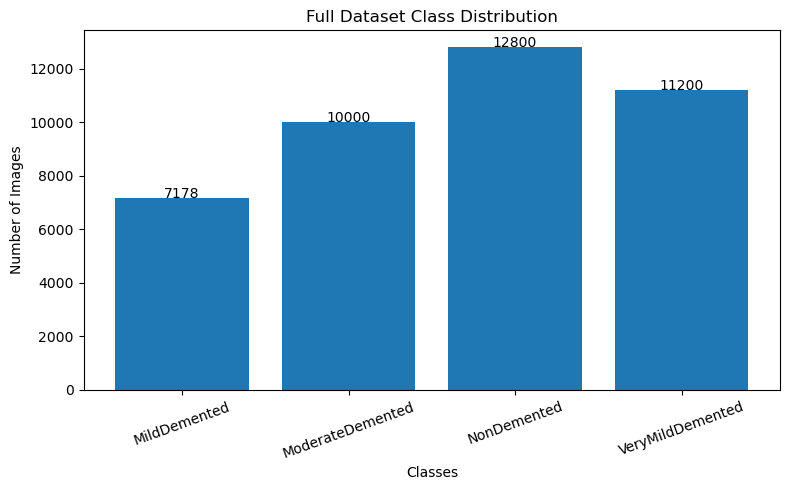

In [58]:
plot_full_dataset_distribution(RAW_PATH)

In [59]:
def show_batch_images(generator, batch_index=0):
    X_batch, y_batch = generator[batch_index]
    class_names = list(generator.class_indices.keys())

    plt.figure(figsize=(10,10))

    for i in range(len(X_batch)):
        plt.subplot(4,8,i+1)
        plt.imshow(X_batch[i])

        label = np.argmax(y_batch[i])
        plt.title(class_names[label], fontsize=8)

        plt.axis("off")

    plt.suptitle("Batch Images", fontsize=14)
    plt.tight_layout()
    plt.show()

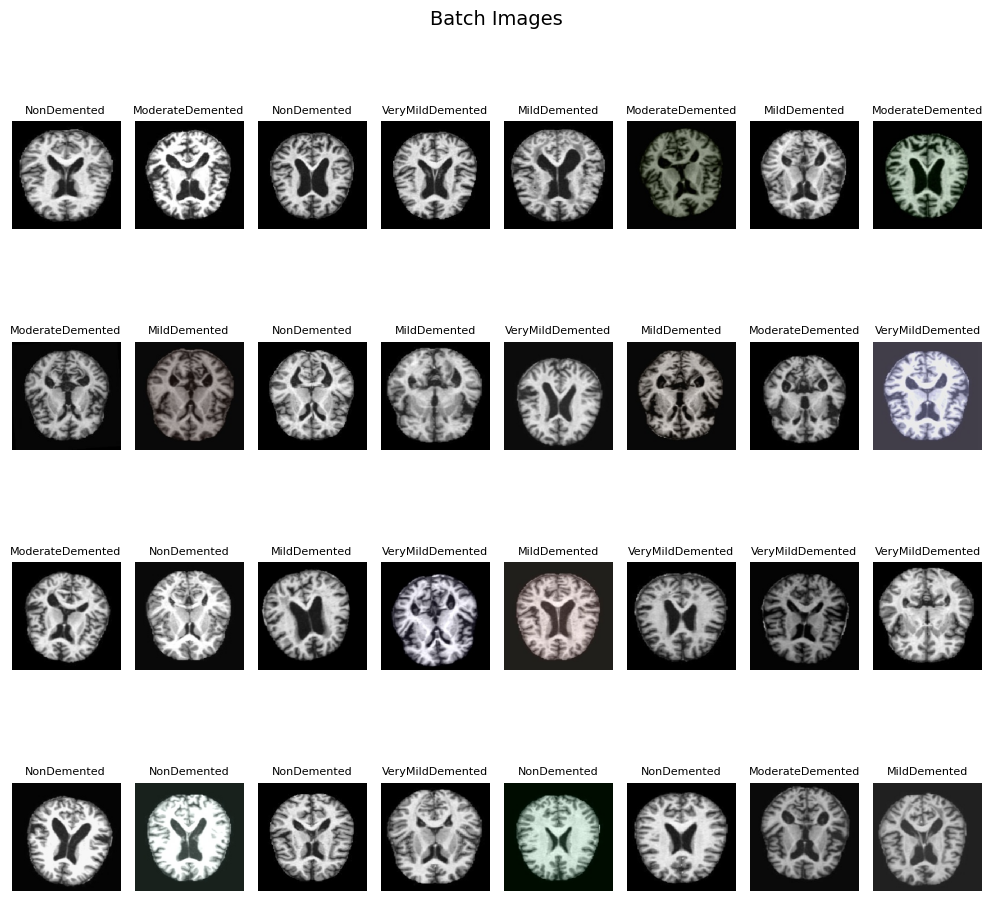

In [60]:
show_batch_images(train_gen, batch_index=0)

In [61]:
from collections import Counter

def plot_batch_distribution(generator, batch_index=0):
    X_batch, y_batch = generator[batch_index]

    labels = np.argmax(y_batch, axis=1)
    counts = Counter(labels)

    class_names = list(generator.class_indices.keys())

    classes = []
    values = []

    for idx, count in counts.items():
        classes.append(class_names[idx])
        values.append(count)

    print("\n📊 Batch Class Distribution:\n")
    for c, v in zip(classes, values):
        print(f"{c}: {v}")

    plt.figure(figsize=(6,4))
    plt.bar(classes, values)

    for i, v in enumerate(values):
        plt.text(i, v + 0.2, str(v), ha='center')

    plt.title(f"Batch {batch_index} Class Distribution")
    plt.xlabel("Classes")
    plt.ylabel("Count")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


📊 Batch Class Distribution:

NonDemented: 9
ModerateDemented: 7
VeryMildDemented: 8
MildDemented: 8


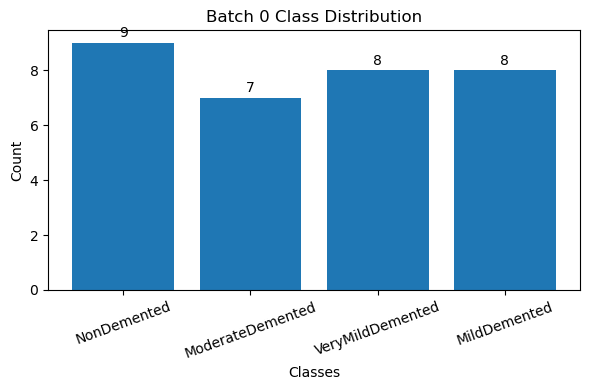

In [62]:
plot_batch_distribution(train_gen, batch_index=0)

In [63]:
base_model = VGG16(weights='imagenet', include_top=False)
vgg_model = Model(inputs=base_model.input, outputs=base_model.output)

In [64]:
def extract_and_save_features(generator, name, model):
    FEATURE_PATH = "models/features"
    os.makedirs(FEATURE_PATH, exist_ok=True)

    X_file = f"{FEATURE_PATH}/X_{name}.npy"
    y_file = f"{FEATURE_PATH}/y_{name}.npy"

    if os.path.exists(X_file):
        print(f"Loading {name}...")
        return np.load(X_file), np.load(y_file)

    print(f"Extracting FULL {name} data...")

    features, labels = [], []

    for i in range(len(generator)):
        X_batch, y_batch = generator[i]

        X_batch = preprocess_input(X_batch * 255.0)

        feat = vgg_model.predict(X_batch, verbose=0)
        feat = feat.reshape(feat.shape[0], -1)

        features.append(feat)
        labels.append(y_batch)

        print(f"{name} batch {i+1}/{len(generator)}")

    X = np.vstack(features)
    y = np.vstack(labels)

    np.save(X_file, X)
    np.save(y_file, y)

    print(f"Saved {name}: {X.shape}")

    return X, y

In [68]:
X_train, y_train = extract_and_save_features(train_gen, "train", vgg_model)
X_val, y_val = extract_and_save_features(val_gen, "val", vgg_model)
X_test, y_test = extract_and_save_features(test_gen, "test", vgg_model)

Extracting FULL train data...
train batch 1/901
train batch 2/901
train batch 3/901
train batch 4/901
train batch 5/901
train batch 6/901
train batch 7/901
train batch 8/901
train batch 9/901
train batch 10/901
train batch 11/901
train batch 12/901
train batch 13/901
train batch 14/901
train batch 15/901
train batch 16/901
train batch 17/901
train batch 18/901
train batch 19/901
train batch 20/901
train batch 21/901
train batch 22/901
train batch 23/901
train batch 24/901
train batch 25/901
train batch 26/901
train batch 27/901
train batch 28/901
train batch 29/901
train batch 30/901
train batch 31/901
train batch 32/901
train batch 33/901
train batch 34/901
train batch 35/901
train batch 36/901
train batch 37/901
train batch 38/901
train batch 39/901
train batch 40/901
train batch 41/901
train batch 42/901
train batch 43/901
train batch 44/901
train batch 45/901
train batch 46/901
train batch 47/901
train batch 48/901
train batch 49/901
train batch 50/901
train batch 51/901
train batc

Executing <Handle BaseAsyncIOLoop._handle_events(1148, 1) created at C:\Users\arnab\anaconda3\envs\p_env\lib\asyncio\selector_events.py:254> took 0.140 seconds


Saved train: (28823, 25088)
Extracting FULL val data...
val batch 1/194
val batch 2/194
val batch 3/194
val batch 4/194
val batch 5/194
val batch 6/194
val batch 7/194
val batch 8/194
val batch 9/194
val batch 10/194
val batch 11/194
val batch 12/194
val batch 13/194
val batch 14/194
val batch 15/194
val batch 16/194
val batch 17/194
val batch 18/194
val batch 19/194
val batch 20/194
val batch 21/194
val batch 22/194
val batch 23/194
val batch 24/194
val batch 25/194
val batch 26/194
val batch 27/194
val batch 28/194
val batch 29/194
val batch 30/194
val batch 31/194
val batch 32/194
val batch 33/194
val batch 34/194
val batch 35/194
val batch 36/194
val batch 37/194
val batch 38/194
val batch 39/194
val batch 40/194
val batch 41/194
val batch 42/194
val batch 43/194
val batch 44/194
val batch 45/194
val batch 46/194
val batch 47/194
val batch 48/194
val batch 49/194
val batch 50/194
val batch 51/194
val batch 52/194
val batch 53/194
val batch 54/194
val batch 55/194
val batch 56/194
v

In [1]:
import numpy as np

FEATURE_PATH = "models/features"

X_train = np.load(f"{FEATURE_PATH}/X_train.npy")
y_train = np.load(f"{FEATURE_PATH}/y_train.npy")

X_val = np.load(f"{FEATURE_PATH}/X_val.npy")
y_val = np.load(f"{FEATURE_PATH}/y_val.npy")

X_test = np.load(f"{FEATURE_PATH}/X_test.npy")
y_test = np.load(f"{FEATURE_PATH}/y_test.npy")

print("✅ Features Loaded")
print("Train shape:", X_train.shape)

✅ Features Loaded
Train shape: (28823, 25088)


In [4]:
import os
import numpy as np
import joblib
from sklearn.decomposition import PCA

In [20]:
PCA_PATH = "models/pca.pkl"
PCA_FEATURE_PATH = "models/pca_features"

# Create folder
os.makedirs(PCA_FEATURE_PATH, exist_ok=True)

In [23]:
def apply_pca(X_train, X_val, X_test):

    # Check ALL files
    files_exist = (
        os.path.exists(PCA_PATH) and
        os.path.exists(f"{PCA_FEATURE_PATH}/X_train_pca.npy") and
        os.path.exists(f"{PCA_FEATURE_PATH}/X_val_pca.npy") and
        os.path.exists(f"{PCA_FEATURE_PATH}/X_test_pca.npy")
    )

    # If everything exists → load
    if files_exist:
        print("PCA + features already exist → loading...")

        X_train_pca = np.load(f"{PCA_FEATURE_PATH}/X_train_pca.npy")
        X_val_pca = np.load(f"{PCA_FEATURE_PATH}/X_val_pca.npy")
        X_test_pca = np.load(f"{PCA_FEATURE_PATH}/X_test_pca.npy")

        return X_train_pca, X_val_pca, X_test_pca

    # Else → recompute everything
    print("Applying PCA (first time or missing files)...")

    pca = PCA(n_components=300)

    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)

    # Save PCA model
    joblib.dump(pca, PCA_PATH)

    # Save PCA features
    np.save(f"{PCA_FEATURE_PATH}/X_train_pca.npy", X_train_pca)
    np.save(f"{PCA_FEATURE_PATH}/X_val_pca.npy", X_val_pca)
    np.save(f"{PCA_FEATURE_PATH}/X_test_pca.npy", X_test_pca)

    print("PCA features saved successfully")

    return X_train_pca, X_val_pca, X_test_pca

In [24]:
X_train, X_val, X_test = apply_pca(X_train, X_val, X_test)

PCA + features already exist → loading...


In [27]:
print(y_train.shape)

(28823,)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [29]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',     # RBF kernel
    C=5,              # slightly lower --> (faster)
    gamma='scale',
    max_iter=2000     # LIMIT TIME
)

svm.fit(X_train, y_train)

print("SVM trained (with PCA)")

SVM trained (with PCA)


C:\Users\arnab\anaconda3\envs\p_env\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [32]:
from sklearn.metrics import classification_report

y_pred = svm.predict(X_val)

print("Validation Report:\n")
print(classification_report(y_val, y_pred))

Validation Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1077
           1       1.00      1.00      1.00      1500
           2       0.98      0.98      0.98      1920
           3       0.97      0.97      0.97      1681

    accuracy                           0.98      6178
   macro avg       0.98      0.98      0.98      6178
weighted avg       0.98      0.98      0.98      6178



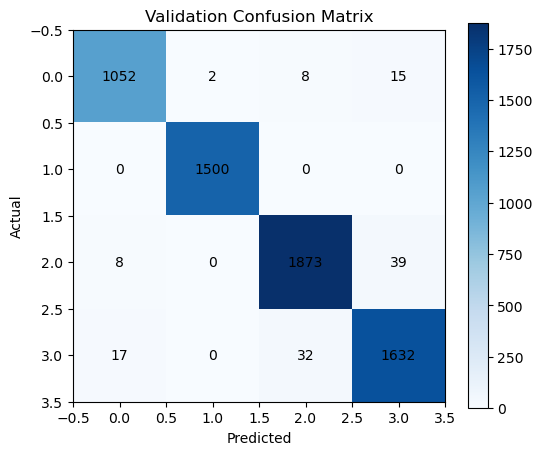

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Validation Confusion Matrix")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
y_test_pred = svm.predict(X_test)

print("Test Report:\n")
print(classification_report(y_test, y_test_pred))

Test Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1077
           1       1.00      1.00      1.00      1500
           2       0.98      0.98      0.98      1920
           3       0.98      0.98      0.98      1680

    accuracy                           0.98      6177
   macro avg       0.98      0.98      0.98      6177
weighted avg       0.98      0.98      0.98      6177



In [35]:
import joblib

joblib.dump(svm, "models/svm_model.pkl")

print("SVM model saved")

SVM model saved


In [41]:
pca = joblib.load("models/pca.pkl")
svm = joblib.load("models/svm_model.pkl")

In [49]:
def predict_image(img_path):
    from tensorflow.keras.preprocessing.image import load_img, img_to_array

    img = load_img(img_path, target_size=(224,224))
    img = img_to_array(img)/255.0
    img = np.expand_dims(img, axis=0)

    img = preprocess_input(img * 255.0)

    feat = vgg_model.predict(img)
    feat = feat.reshape(1, -1)

    # PCA
    feat = pca.transform(feat)

    pred = svm.predict(feat)[0]

    return list(train_gen.class_indices.keys())[pred]

In [65]:
BASE_PATH = r"D:\CODE\Alzheimer_Detection_And_Classification\data"
test_img = BASE_PATH + "/test/NonDemented/" + os.listdir(BASE_PATH + "/test/NonDemented")[0]

print("Prediction:", predict_image(test_img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Prediction: NonDemented
